# Market Trend Analysis

## Predicting Market Trends Using Financial Time-Series Data

**Project Track:** AI Applications – Market Trend Analysis  
**Data Source:** Yahoo Finance (yfinance)  
**Models Used:** Random Forest, Gradient Boosting (Ensemble)

This project develops an AI-based system that analyzes historical market data
to identify trends and generate confidence-aware predictive signals.*italicized text*

## 1. Problem Definition & Objective

Financial markets are highly dynamic, noisy, and non-stationary.
Traditional rule-based analysis fails to capture complex, non-linear
patterns and regime changes.

### Objective
The objective of this project is to build an AI system that:
- Learns patterns from historical market price data
- Identifies trend and volatility regimes
- Generates probabilistic market trend signals
- Acts as a decision-support system rather than a deterministic predictor

## 2. Data Source & Understanding

The dataset is obtained using the `yfinance` API, which provides
real-world historical market data from Yahoo Finance.

### Data Characteristics
- Open, High, Low, Close prices
- Trading volume
- Daily frequency
- Real financial market data

The system is symbol-agnostic and works for indices or individual equities.

In [164]:
import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [177]:
SYMBOL = "AAPL"
START_DATE = "2019-01-01"
END_DATE = "2026-01-01"

df = yf.download(SYMBOL, start=START_DATE, end=END_DATE)
df.columns = df.columns.get_level_values(0)
df.dropna(inplace=True)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.538834,37.759904,36.661691,36.818579,148158800
2019-01-03,33.799675,34.638783,33.754510,34.225170,365248800
2019-01-04,35.242558,35.311495,34.182383,34.355908,234428400
2019-01-07,35.164120,35.378059,34.681573,35.347156,219111200
2019-01-08,35.834454,36.088803,35.304366,35.551581,164101200


## 3. Feature Engineering

Raw price data alone is insufficient to capture market behavior.
Therefore, multiple derived features are created to represent:

- Price momentum
- Volatility
- Trend direction
- Market regimes

In [178]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

df["vol_5"] = df["log_return"].rolling(5).std()
df["vol_20"] = df["log_return"].rolling(20).std()

df["ma_10"] = df["Close"].rolling(10).mean()
df["ma_50"] = df["Close"].rolling(50).mean()
df["ma_200"] = df["Close"].rolling(200).mean()

df["ma_ratio_10_50"] = df["ma_10"] / df["ma_50"]
df["ma_ratio_50_200"] = df["ma_50"] / df["ma_200"]

df["momentum_10"] = df["Close"] - df["Close"].shift(10)
df["momentum_30"] = df["Close"] - df["Close"].shift(30)

df["volume_zscore"] = (
    (df["Volume"] - df["Volume"].rolling(20).mean()) /
    df["Volume"].rolling(20).std()
)

df["range_pct"] = (df["High"] - df["Low"]) / df["Close"]

df.dropna(inplace=True)

## 4. Market Regime Identification

Market behavior differs across trend and volatility regimes.
Explicit regime features help the model adapt to these changes.

In [179]:
df["trend_regime"] = 0
df.loc[df["ma_50"] > df["ma_200"], "trend_regime"] = 1
df.loc[df["ma_50"] < df["ma_200"], "trend_regime"] = -1

df["volatility_regime"] = np.where(
    df["vol_20"] > df["vol_20"].rolling(60).mean(),
    1,
    0
)

df["trend_strength"] = np.abs(df["ma_ratio_50_200"] - 1)

## 5. Target Variable Definition

The task is formulated as a binary directional prediction problem.

- `1` → Price moves upward over a fixed horizon
- `0` → No upward movement

This reflects realistic market decision-making.

In [180]:
HORIZON = 5

future_return = np.log(
    df["Close"].shift(-HORIZON).values / df["Close"].values
)

df["target"] = (future_return > 0).astype(int)

df.dropna(inplace=True)
df["target"].value_counts()

,count
target,
1,896
0,665


## 6. Model / System Design

### Techniques Used
- Supervised Machine Learning
- Ensemble Learning
- Probability Calibration

### Models
- Random Forest Classifier
- Gradient Boosting Classifier

In [181]:
FEATURES = [
    "log_return",
    "vol_5",
    "vol_20",
    "ma_ratio_10_50",
    "ma_ratio_50_200",
    "momentum_10",
    "momentum_30",
    "volume_zscore",
    "range_pct",
    "trend_regime",
    "volatility_regime",
    "trend_strength"
]

X = df[FEATURES]
y = df["target"]

X_train, X_test = X.iloc[:-500], X.iloc[-500:]
y_train, y_test = y.iloc[:-500], y.iloc[-500:]

## 7. Training & Inference Pipeline

The system uses an ensemble with calibrated probability outputs.
Predictions are generated only when confidence exceeds a threshold.

In [182]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", rf)
])

gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", gb)
])

gb_pipeline.fit(X_train, y_train)

from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(
    rf_pipeline,
    method="isotonic",
    cv=3
)

rf_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('model',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=8,
                                                                         min_samples_leaf=20,
                                                                         n_estimators=400,
                                                                         random_state=42))]),
                       method='isotonic')

In [183]:
rf_probs = rf_calibrated.predict_proba(X_test)
gb_probs = gb_pipeline.predict_proba(X_test)

ensemble_probs = 0.5 * rf_probs + 0.5 * gb_probs

confidence_threshold = 0.6
ensemble_preds = (ensemble_probs[:, 1] > confidence_threshold).astype(int)

## 8. Evaluation & Analysis

Due to market noise, performance is evaluated using:
- Accuracy
- ROC-AUC
- Prediction coverage
- High-confidence accuracy

In [184]:
confidence_mask = ensemble_probs[:, 1] > confidence_threshold

print("Coverage:", confidence_mask.mean())
print(
    "High-confidence accuracy:",
    accuracy_score(
        y_test[confidence_mask],
        ensemble_preds[confidence_mask]
    )
)

print("Accuracy:", accuracy_score(y_test, ensemble_preds))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_probs[:, 1]))
print("\nReport:\n")
print(classification_report(y_test, ensemble_preds))

Coverage: 0.378
High-confidence accuracy: 0.544973544973545
Accuracy: 0.484
ROC-AUC: 0.5064727272727272

Report:

              precision    recall  f1-score   support

           0       0.45      0.62      0.52       225
           1       0.54      0.37      0.44       275

    accuracy                           0.48       500
   macro avg       0.50      0.50      0.48       500
weighted avg       0.50      0.48      0.48       500



## 9. Feature Importance Analysis

Feature importance provides interpretability and insight
into which market factors influence model decisions.

In [185]:
rf_importances = []

for calibrated_clf in rf_calibrated.calibrated_classifiers_:
    rf_model = calibrated_clf.estimator.named_steps["model"]
    rf_importances.append(rf_model.feature_importances_)

rf_importance = np.mean(rf_importances, axis=0)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
4,ma_ratio_50_200,0.139113
5,momentum_10,0.135258
2,vol_20,0.132232
11,trend_strength,0.116818
3,ma_ratio_10_50,0.105413
1,vol_5,0.098282
6,momentum_30,0.097110
8,range_pct,0.047020
7,volume_zscore,0.046222
10,volatility_regime,0.042455


## 10. Signal Visualization

Bullish signals are visualized on the price chart.
Neutral and bearish conditions are treated as no-trade scenarios.

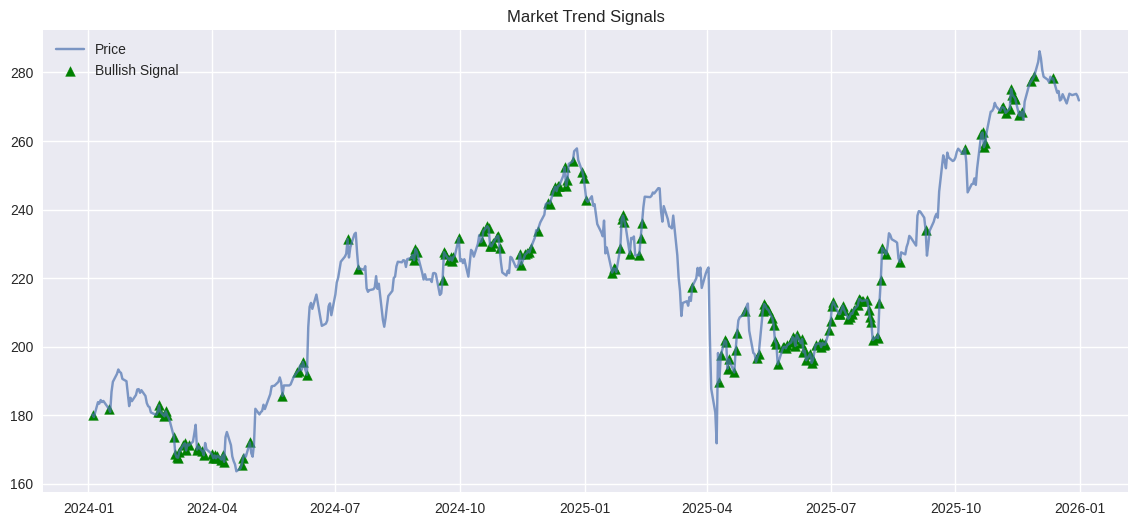

In [186]:
signals = pd.Series(ensemble_preds, index=X_test.index)

plt.figure(figsize=(14,6))
plt.plot(df.loc[X_test.index, "Close"], label="Price", alpha=0.7)

plt.scatter(
    signals[signals == 1].index,
    df.loc[signals[signals == 1].index, "Close"],
    label="Bullish Signal",
    marker="^",
    color="green"
)

plt.legend()
plt.title("Market Trend Signals")
plt.show()

## 11. Ethical Considerations & Conclusion

### Ethical Considerations
- No personal or sensitive data is used
- Predictions are probabilistic, not financial advice
- Human judgment is required before real-world use

### Conclusion
This project demonstrates how AI techniques can be applied
to real-world financial data for market trend analysis.

Future extensions include deep learning models, sentiment analysis,
and real-time deployment.